In [1]:
import pygmt
import pandas as pd
import h5py
import numpy as np

In [4]:
with h5py.File('OUTPUT_FILES/initial_model.h5', 'r') as f:
    print(f.keys())
    vsi = f['vs'][:]
    x = f['x'][:]
    y = f['y'][:]
    z = f['z'][:]
with h5py.File('OUTPUT_FILES/final_model.h5', 'r') as f:
    vst = f['vs'][:]

dv = (vst - vsi) / vsi * 100

<KeysViewHDF5 ['vs', 'x', 'y', 'z']>


Plotting depth slice at z=1.50 km (index 3)


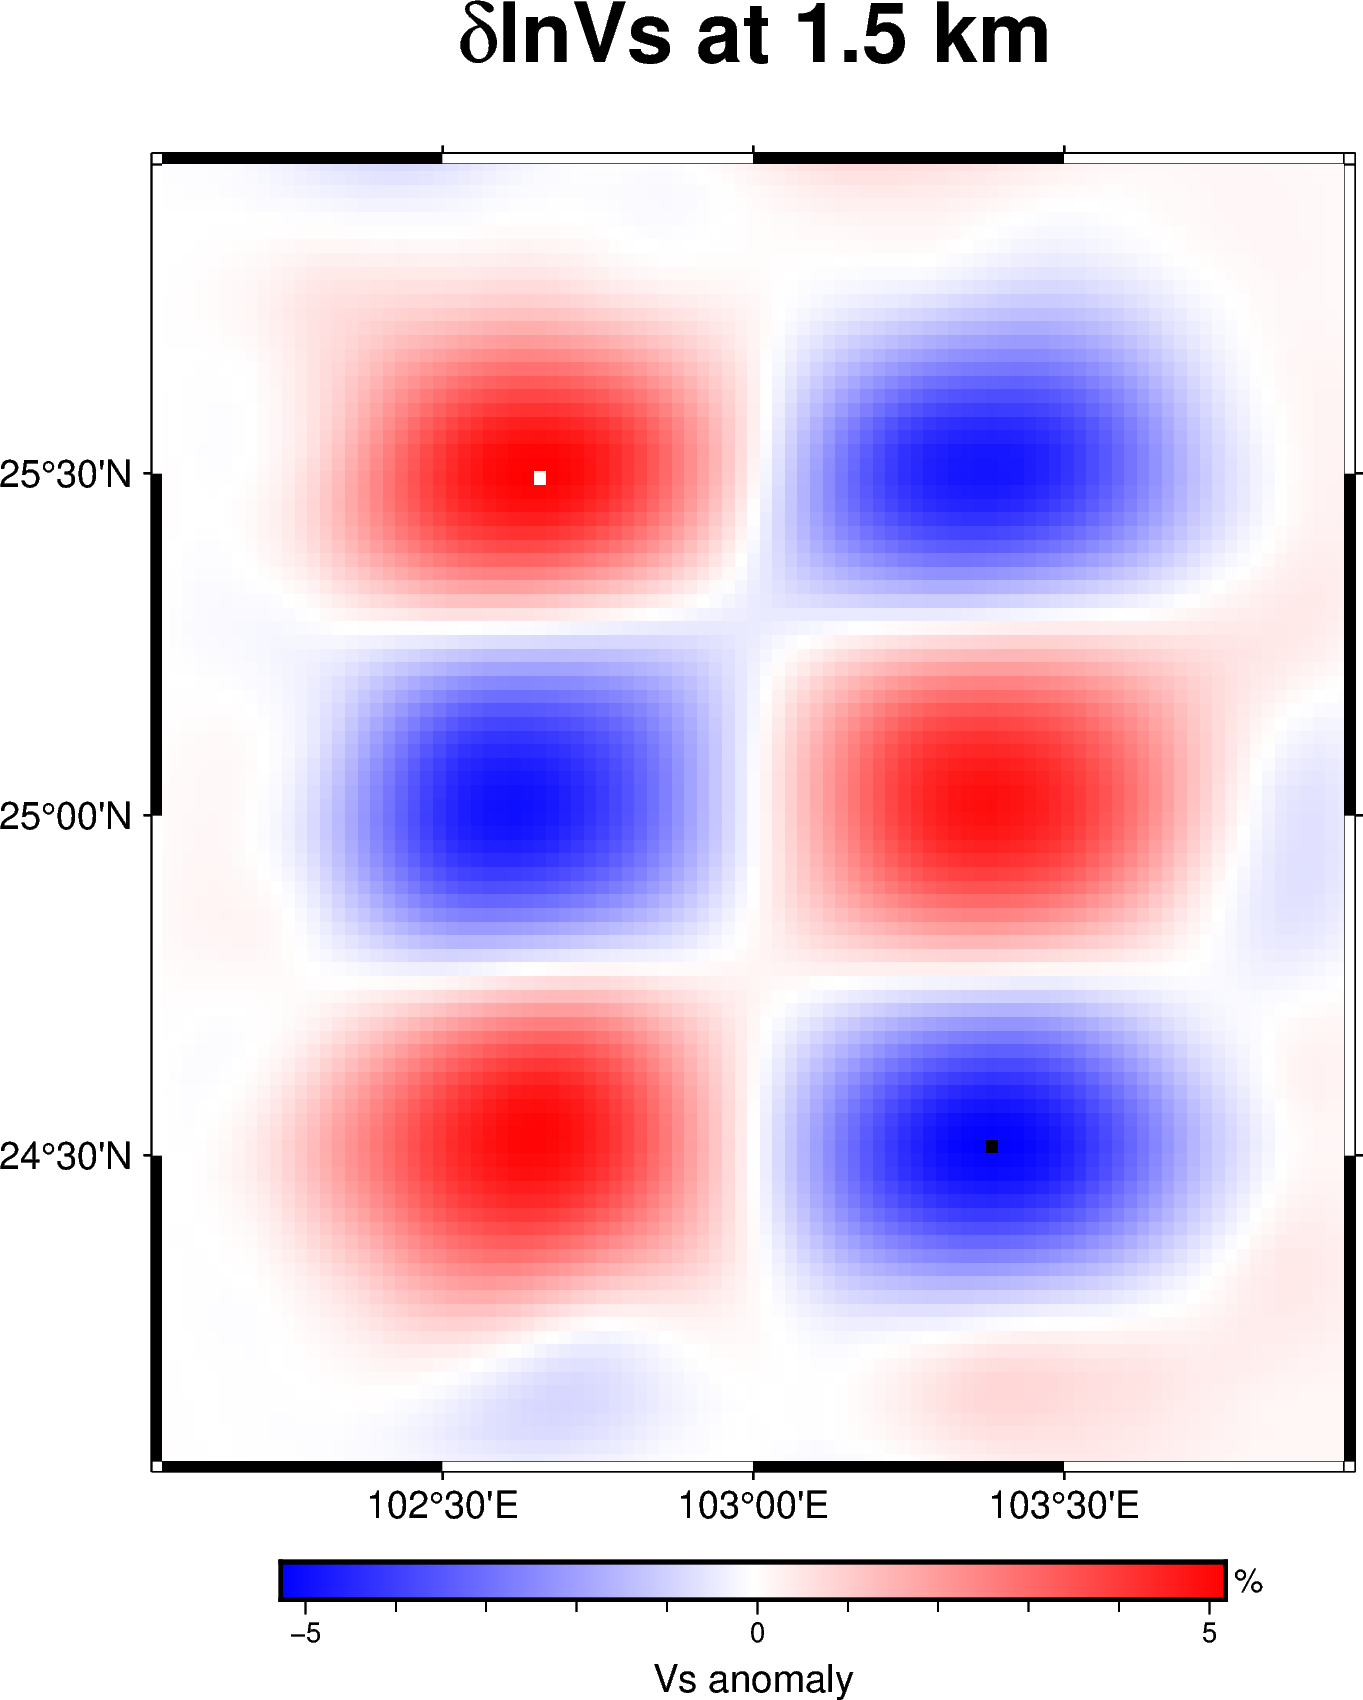

In [5]:

# 深度切片 1.5 km
depth = 1.5
iz = np.argmin(np.abs(z - depth))
print(f"Plotting depth slice at z={z[iz]:.2f} km (index {iz})")

# dv shape: (nx, ny, nz), depth slice -> (nx, ny)
slice2d = dv[:, :, iz]

xx, yy = np.meshgrid(x, y)  # xx, yy shape: (ny, nx)
# flatten in same order as meshgrid
x_flat = xx.flatten()
y_flat = yy.flatten()
z_flat = slice2d.T.flatten()  # transpose to (ny, nx) then flatten

fig = pygmt.Figure()
region = [x.min(), x.max(), y.min(), y.max()]
spacing = [x[1] - x[0], y[1] - y[0]]

grid = pygmt.xyz2grd(
    x=x_flat, y=y_flat, z=z_flat,
    region=region,
    spacing=spacing,
)

pygmt.makecpt(cmap="polar", series=[z_flat.min(), z_flat.max()])

fig.basemap(region=region, projection="M10c", frame=["WSen+t@~d@~lnVs at {:.1f} km".format(z[iz]), "xa", "ya"])
fig.grdimage(grid=grid, cmap=True)
fig.colorbar(frame=["x+lVs anomaly", "y+l%"])
fig.show()


Plotting cross-section at y=24.9900 (index 47)


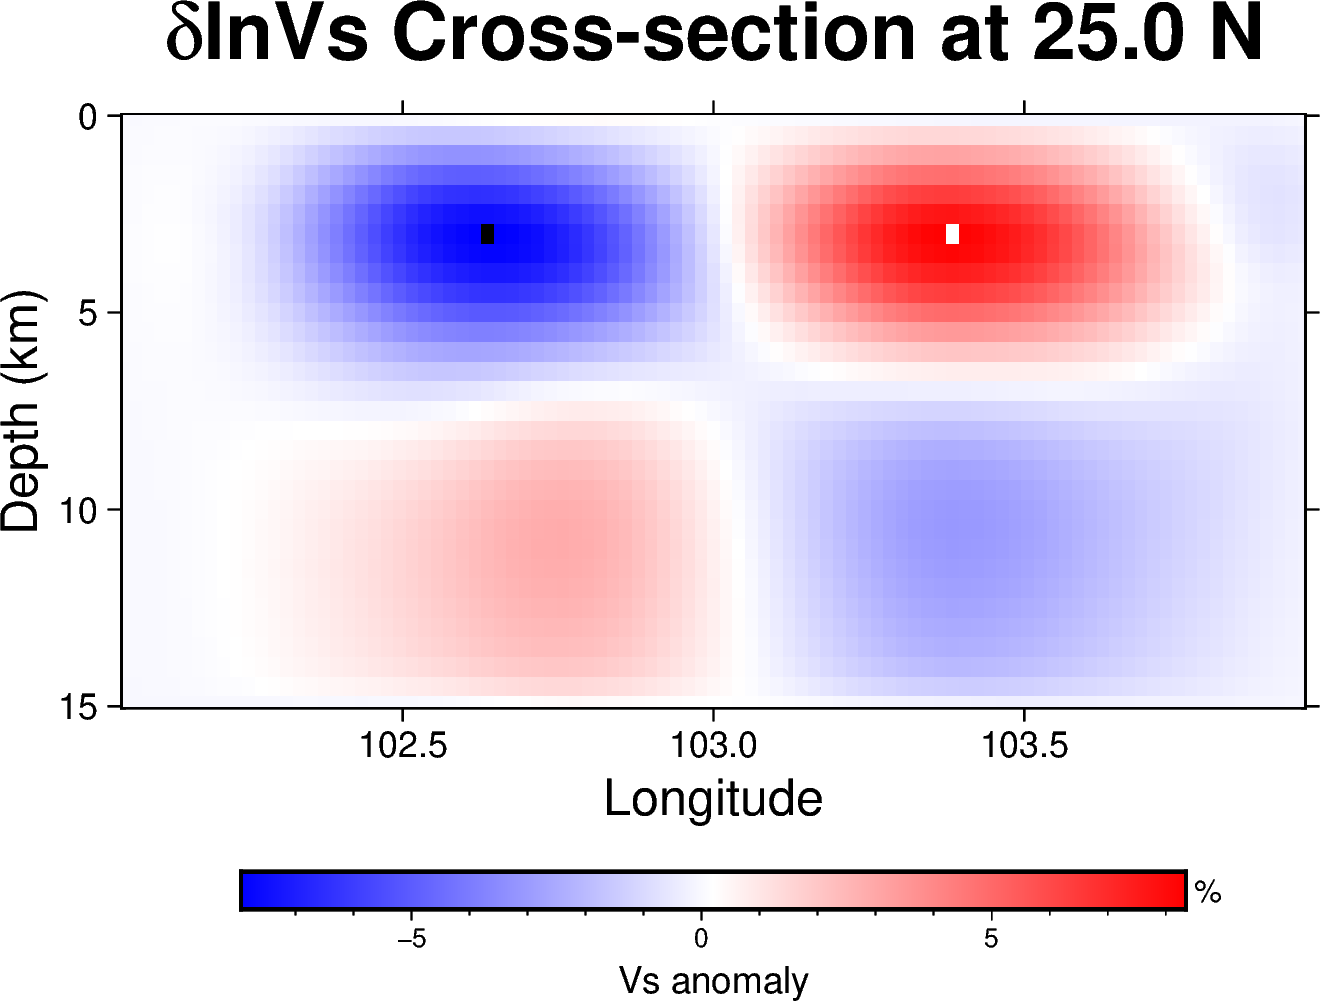

In [6]:

# Cross-section at y=25
lat = 25.0
iy = np.argmin(np.abs(y - lat))
print(f"Plotting cross-section at y={y[iy]:.4f} (index {iy})")

# dv shape: (nx, ny, nz), cross-section -> (nx, nz)
slice_cs = dv[:, iy, :]  # shape (nx, nz)

xx, zz = np.meshgrid(x, z)  # shape (nz, nx)
x_flat = xx.flatten()
z_flat = zz.flatten()
v_flat = slice_cs.T.flatten()  # transpose to (nz, nx) then flatten

fig = pygmt.Figure()
# Use normal region ordering for GMT; negative projection height flips depth axis
region = [x.min(), x.max(), z.min(), z.max()]
spacing = [x[1] - x[0], z[1] - z[0]]

grid = pygmt.xyz2grd(
    x=x_flat, y=z_flat, z=v_flat,
    region=region,
    spacing=spacing,
)

pygmt.makecpt(cmap="polar", series=[v_flat.min(), v_flat.max()])

title = "@~d@~lnVs Cross-section at {:.1f} N".format(y[iy])
fig.basemap(
    region=region,
    projection="X10c/-5c",  # negative height: y-axis increases downward
    frame=["WSen+t{}".format(title), "xa+lLongitude", "ya+lDepth (km)"],
)
fig.grdimage(grid=grid, cmap=True)
fig.colorbar(frame=["x+lVs anomaly", "y+l%"])
fig.show()
